Opening file explorer... (Check your taskbar if it doesn't pop up immediately)
Image successfully loaded from: C:/Users/ADV/Universita/Magistrale/Tesi/vad-project/data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg


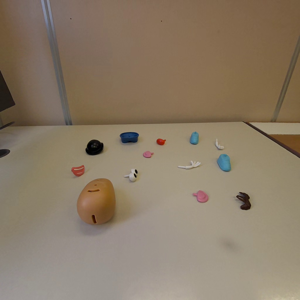

In [1]:
# Cell 1: Select Image via OS File Explorer (tkinter)
import tkinter as tk
from tkinter import filedialog
from PIL import Image
from IPython.display import display
import os

print("Opening file explorer... (Check your taskbar if it doesn't pop up immediately)")

# Initialize tkinter
root = tk.Tk()
root.attributes('-topmost', True)  # Force window to the front
root.withdraw()  # Hide the root window

# Open the native OS file dialog
image_path = filedialog.askopenfilename(
    title="Select an Image",
    initialdir="../data/extracted_frames/",
    filetypes=[
        ("Image Files", "*.jpg;*.jpeg;*.png"),
        ("All Files", "*.*")
    ]
)

# Destroy the root window to prevent Jupyter from freezing
root.destroy()

if image_path and os.path.exists(image_path):
    print(f"Image successfully loaded from: {image_path}")
    image = Image.open(image_path).convert('RGB')
    
    # Show a small preview in the notebook
    preview = image.copy()
    preview.thumbnail((300, 300))
    display(preview)
else:
    print("No image selected or file not found. Please run the cell again.")

In [2]:
# Cell 2: Load C-RADIOv4 model
import os
import torch
from transformers import AutoModel, CLIPImageProcessor

# Adjusted path to match the directory depth of your data folder
local_repo = "../models/c_radio_weights" 

# Verify the directory exists before trying to load
if not os.path.exists(local_repo):
    print(f"ERROR: Cannot find the directory at:\n{os.path.abspath(local_repo)}")
    print("Please verify the exact name and location of your 'c_radio_weights' folder.")
else:
    print(f"Loading model from local path: {os.path.abspath(local_repo)}...")
    
    image_processor = CLIPImageProcessor.from_pretrained(local_repo)
    model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)
    model.eval().cuda()
    
    print("Model loaded successfully into VRAM!")

Loading model from local path: c:\Users\ADV\Universita\Magistrale\Tesi\vad-project\models\c_radio_weights...


Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

Model loaded successfully into VRAM!


1. Calculating optimal high-resolution input...
Original size: 1024x1024 -> Target size: 1024x1024
2. Extracting high-density spatial features...
Feature grid size: 64x64 patches
3. Computing Robust PCA (Fitting only on central features)...
4. Normalizing for RGB visualization...
5. Plotting results...


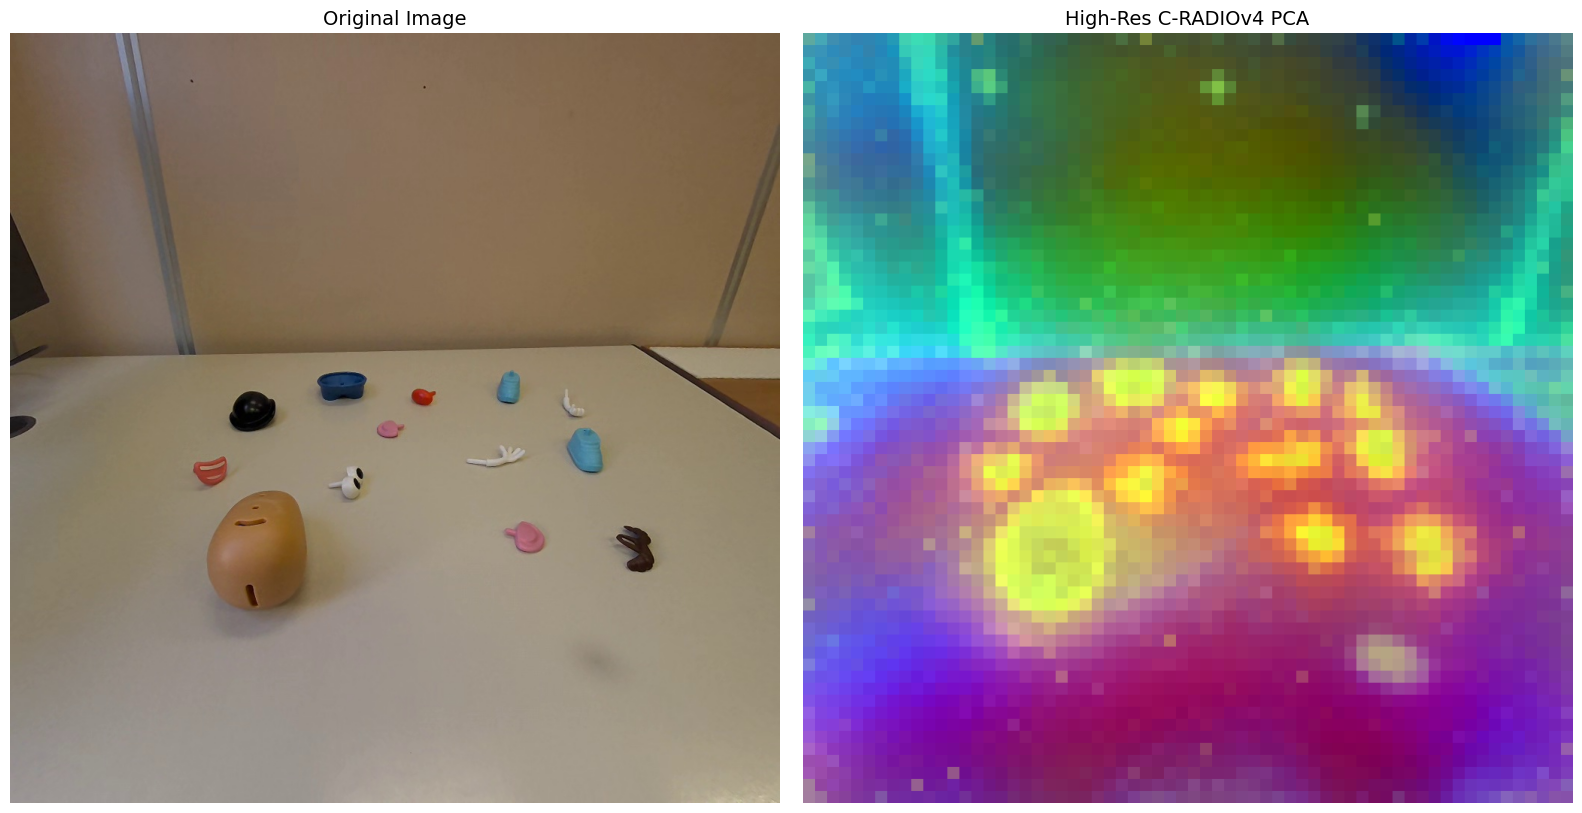

In [3]:
# Cell 3: High-Resolution Feature Extraction & Tech Report Style PCA
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from einops import rearrange
from sklearn.decomposition import PCA

print("1. Calculating optimal high-resolution input...")

nearest_h, nearest_w = model.get_nearest_supported_resolution(height=image.height, width=image.width)
print(f"Original size: {image.width}x{image.height} -> Target size: {nearest_w}x{nearest_h}")

image_resized = image.resize((nearest_w, nearest_h), Image.Resampling.LANCZOS)

inputs = image_processor(images=image_resized, return_tensors='pt', do_resize=False)
pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')

print("2. Extracting high-density spatial features...")
with torch.no_grad():
    with torch.autocast('cuda', dtype=torch.bfloat16):
        summary, features = model(pixel_values)

patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
h_feat = nearest_h // patch_size
w_feat = nearest_w // patch_size
spatial_features = rearrange(features, 'b (h w) d -> b d h w', h=h_feat, w=w_feat)

print(f"Feature grid size: {w_feat}x{h_feat} patches")

print("3. Computing Robust PCA (Fitting only on central features)...")
c = spatial_features.shape[1]
margin = 2
central_features = spatial_features[0, :, margin:-margin, margin:-margin]
features_for_fit = central_features.permute(1, 2, 0).reshape(-1, c).float().cpu().numpy()

pca = PCA(n_components=3)
pca.fit(features_for_fit)

features_all = spatial_features.squeeze(0).permute(1, 2, 0).reshape(-1, c).float().cpu().numpy()
pca_features = pca.transform(features_all)

print("4. Normalizing for RGB visualization...")
pca_cleaned = np.zeros_like(pca_features)
for i in range(3):
    comp = pca_features[:, i]
    p_min, p_max = np.percentile(comp, 1), np.percentile(comp, 99)
    comp_clipped = np.clip(comp, p_min, p_max)
    pca_cleaned[:, i] = (comp_clipped - p_min) / (p_max - p_min + 1e-8)

pca_grid = pca_cleaned.reshape(h_feat, w_feat, 3)

pca_resized_plot = cv2.resize(pca_grid, (image.width, image.height), interpolation=cv2.INTER_NEAREST)

print("5. Plotting results...")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(pca_resized_plot)
axes[1].set_title("High-Res C-RADIOv4 PCA", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Cell 4: reusable function to extract spatial features from any PIL image
# (same logic as Cell 3, but wrapped in a function so we can call it once for the
#  reference frame and once for the test frame, without reloading the model,
#  which stays in VRAM since Cell 2)

import numpy as np
import torch
from einops import rearrange
from PIL import Image

def extract_spatial_features(pil_image):
    """
    Input: a PIL image (RGB)
    Output:
    - spatial_features: torch tensor [1, C, h_feat, w_feat] -> for each position
      (row, col) of the patch grid, a C-dimensional vector (C ~ 1152 for SO400M)
    - h_feat, w_feat: number of rows/columns in the patch grid
    - resized_size: (nearest_w, nearest_h), the resolution the image was actually
      resized to before entering the model. We need this to correctly convert
      polygon coordinates (which are in the original image) into patch grid
      coordinates in the next step.
    """
    nearest_h, nearest_w = model.get_nearest_supported_resolution(
        height=pil_image.height, width=pil_image.width
    )
    image_resized = pil_image.resize((nearest_w, nearest_h), Image.Resampling.LANCZOS)

    inputs = image_processor(images=image_resized, return_tensors='pt', do_resize=False)
    pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')

    with torch.no_grad():
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, features = model(pixel_values)

    patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
    h_feat = nearest_h // patch_size
    w_feat = nearest_w // patch_size
    spatial_features = rearrange(features, 'b (h w) d -> b d h w', h=h_feat, w=w_feat)

    return spatial_features, h_feat, w_feat, (nearest_w, nearest_h)

In [5]:
%pip install shapely

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Cell 5: build per-part prototypes, pooling patches across ALL annotated reference frames

import json
from shapely.geometry import Point, Polygon

REFERENCE_FRAMES = [
    ("../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg",
     "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json"),
    ("../data/extracted_frames/caos_f0149.jpg",
     "../data/extracted_frames/caos_f0149.json"),
    ("../data/extracted_frames/assembly_1_f0073.jpg",
     "../data/extracted_frames/assembly_1_f0073.json"),
    ("../data/extracted_frames/5_assembled_f0002.jpg",
     "../data/extracted_frames/5_assembled_f0002.json"),
    ("../data/extracted_frames/5_assembled_f0019.jpg",
     "../data/extracted_frames/5_assembled_f0019.json"),
]

patch_size = model.patch_size if hasattr(model, 'patch_size') else 16

# collect ALL patch feature vectors per label, across every reference frame
label_to_vectors = {}  # label -> list of arrays of feature vectors

for image_path, json_path in REFERENCE_FRAMES:
    print(f"Processing {image_path}...")
    reference_image = Image.open(image_path).convert("RGB")
    ref_features, ref_h_feat, ref_w_feat, (ref_resized_w, ref_resized_h) = extract_spatial_features(reference_image)
    ref_features_np = ref_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()  # [h, w, C]

    with open(json_path, "r") as f:
        annotations = json.load(f)

    scale_x = ref_resized_w / annotations["imageWidth"]
    scale_y = ref_resized_h / annotations["imageHeight"]
    polygons = [(shape["label"], Polygon(shape["points"])) for shape in annotations["shapes"]]

    frame_patch_labels = np.full((ref_h_feat, ref_w_feat), "background", dtype=object)
    for row in range(ref_h_feat):
        for col in range(ref_w_feat):
            center_x_orig = ((col + 0.5) * patch_size) / scale_x
            center_y_orig = ((row + 0.5) * patch_size) / scale_y
            point = Point(center_x_orig, center_y_orig)
            for label, polygon in polygons:
                if polygon.contains(point):
                    frame_patch_labels[row, col] = label
                    break  # first matching polygon wins

    for label in set(frame_patch_labels.flatten()):
        mask = (frame_patch_labels == label)
        label_to_vectors.setdefault(label, []).append(ref_features_np[mask])
        print(f"  '{label}': {mask.sum()} patches")

# one prototype per label = mean of ALL patches of that label, pooled across every frame
prototypes = {}
for label, vector_chunks in label_to_vectors.items():
    prototypes[label] = np.concatenate(vector_chunks, axis=0).mean(axis=0)

print(f"\nBuilt {len(prototypes)} prototypes (pooled over {len(REFERENCE_FRAMES)} frames):")
for label in prototypes:
    total = sum(v.shape[0] for v in label_to_vectors[label])
    print(f"  '{label}': {total} total patches pooled")

Processing ../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg...
  'arm_2': 2 patches
  'ear': 7 patches
  'eyes': 5 patches
  'pants': 8 patches
  'body': 66 patches
  'shoe': 10 patches
  'hat': 10 patches
  'arm_1': 5 patches
  'mouth': 5 patches
  'nose': 2 patches
  'background': 3970 patches
  'moustache': 6 patches
Processing ../data/extracted_frames/caos_f0149.jpg...
  'ear': 11 patches
  'eyes': 6 patches
  'body': 45 patches
  'shoe': 31 patches
  'nose': 11 patches
  'hat': 6 patches
  'arm_1': 16 patches
  'mouth': 1 patches
  'pants': 29 patches
  'background': 3929 patches
  'moustache': 11 patches
Processing ../data/extracted_frames/assembly_1_f0073.jpg...
  'ear': 14 patches
  'arm_2': 5 patches
  'body': 59 patches
  'shoe': 21 patches
  'hat': 17 patches
  'arm_1': 9 patches
  'pants': 5 patches
  'background': 3966 patches
Processing ../data/extracted_frames/5_assembled_f0002.jpg...
  'ear': 12 patches
  'arm_2': 4 patches
  'eyes': 8 patches
  'pants'

In [7]:
# Cell 6a: also build a "background" prototype (table/wall), needed so that
# background patches in the test frame don't get forced into a wrong part class

background_mask = (frame_patch_labels == "background")
prototypes["background"] = ref_features_np[background_mask].mean(axis=0)
print(f"'background': {background_mask.sum()} patches used for the prototype")

'background': 3985 patches used for the prototype


In [8]:
# Cell 6b: classify every patch of a TEST frame against the reference prototypes

TEST_IMAGE_PATH = "../data/extracted_frames/3_disassembled_ordered_f0001.jpg"

test_image = Image.open(TEST_IMAGE_PATH).convert("RGB")
test_features, test_h_feat, test_w_feat, _ = extract_spatial_features(test_image)
test_features_np = test_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()  # [h, w, C]

label_names = list(prototypes.keys())
prototype_matrix = np.stack([prototypes[label] for label in label_names])  # [num_classes, C]

# normalize everything so that a simple dot product = cosine similarity
def normalize(v):
    return v / (np.linalg.norm(v, axis=-1, keepdims=True) + 1e-8)

prototype_matrix_norm = normalize(prototype_matrix)
test_features_flat = test_features_np.reshape(-1, test_features_np.shape[-1])
test_features_norm = normalize(test_features_flat)

similarities = test_features_norm @ prototype_matrix_norm.T  # [num_patches, num_classes]
predicted_indices = similarities.argmax(axis=1)
predicted_labels = np.array(label_names)[predicted_indices].reshape(test_h_feat, test_w_feat)

print(f"Test image: {test_image.width}x{test_image.height}, patch grid: {test_w_feat}x{test_h_feat}")
print("Predicted label counts:")
for label in label_names:
    print(f"  {label}: {(predicted_labels == label).sum()} patches")

Test image: 1024x1024, patch grid: 64x64
Predicted label counts:
  arm_2: 12 patches
  ear: 1 patches
  eyes: 11 patches
  pants: 98 patches
  body: 111 patches
  shoe: 104 patches
  hat: 20 patches
  arm_1: 18 patches
  mouth: 9 patches
  nose: 26 patches
  background: 3650 patches
  moustache: 36 patches


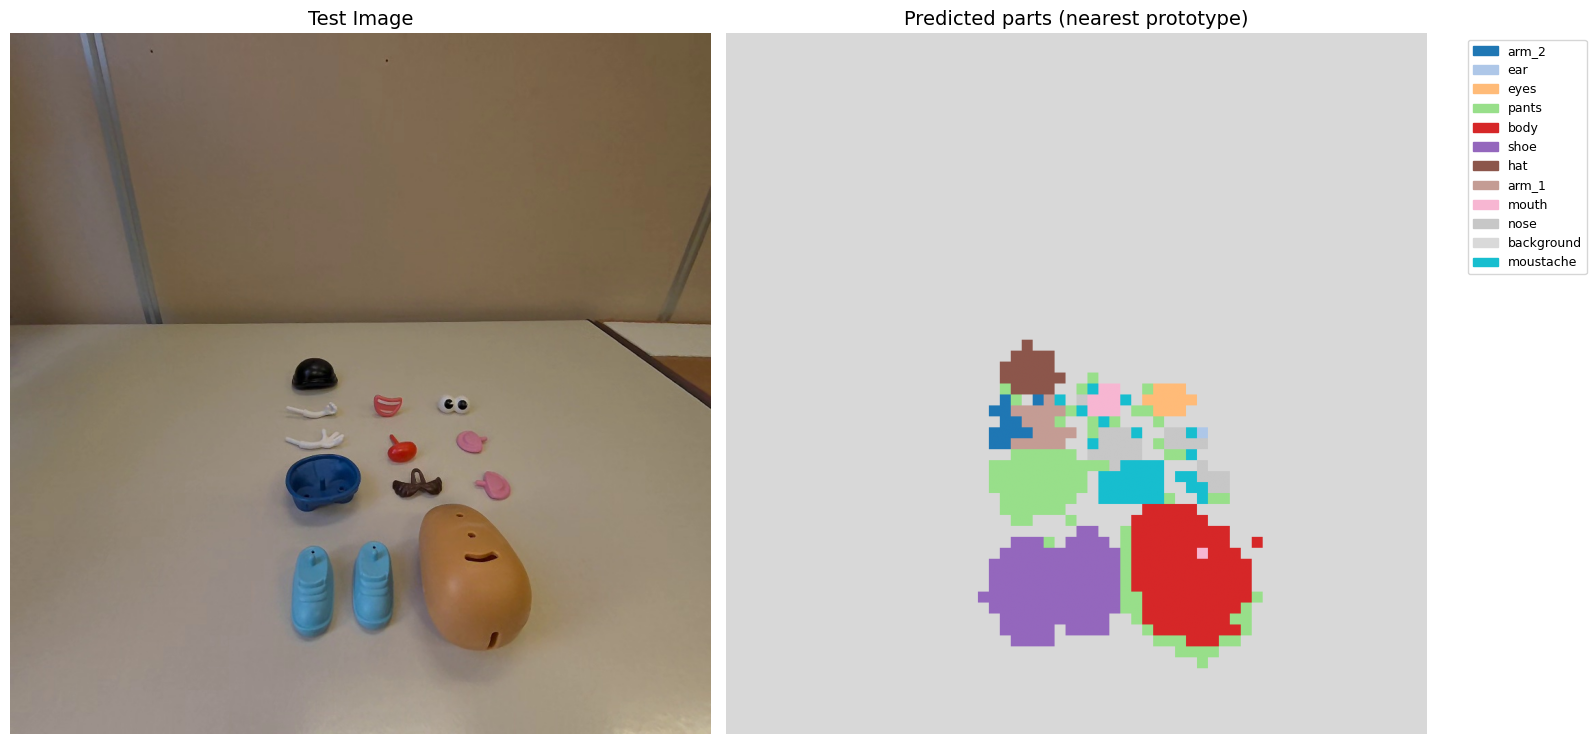

In [9]:
# Cell 7: visualize the predicted label map side by side with the test image

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# assign a fixed, distinct color to each label so the legend stays readable
cmap = plt.get_cmap("tab20")
label_to_color = {label: cmap(i / len(label_names))[:3] for i, label in enumerate(label_names)}
label_to_color["background"] = (0.85, 0.85, 0.85)  # light grey, easy to tell apart

color_grid = np.zeros((test_h_feat, test_w_feat, 3))
for row in range(test_h_feat):
    for col in range(test_w_feat):
        color_grid[row, col] = label_to_color[predicted_labels[row, col]]

color_grid_resized = cv2.resize(
    color_grid, (test_image.width, test_image.height), interpolation=cv2.INTER_NEAREST
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(test_image)
axes[0].set_title("Test Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(color_grid_resized)
axes[1].set_title("Predicted parts (nearest prototype)", fontsize=14)
axes[1].axis("off")

legend_patches = [mpatches.Patch(color=label_to_color[l], label=l) for l in label_names]
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

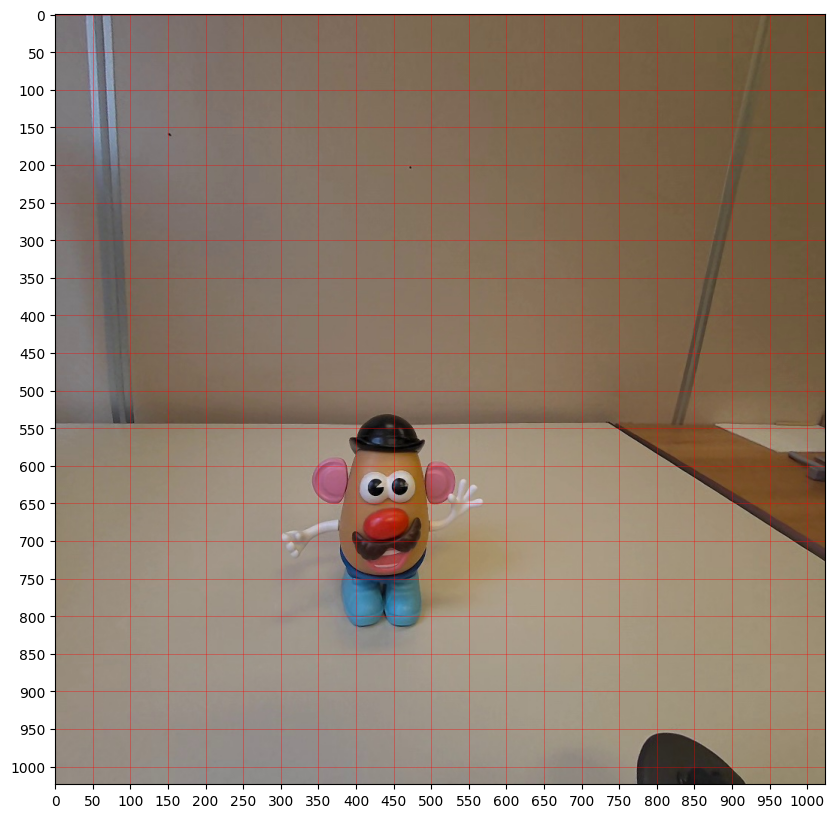

In [10]:
# Cell 8a: display the test frame with a pixel grid, to help pick the crop box
TEST_IMAGE_PATH = "../data/extracted_frames/caos_f0393.jpg"  # pick one with a clean, unoccluded view of nose/moustache/mouth

test_image_full = Image.open(TEST_IMAGE_PATH).convert("RGB")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(test_image_full)
ax.set_xticks(np.arange(0, test_image_full.width, 50))
ax.set_yticks(np.arange(0, test_image_full.height, 50))
ax.grid(color="red", linewidth=0.5, alpha=0.5)
plt.show()

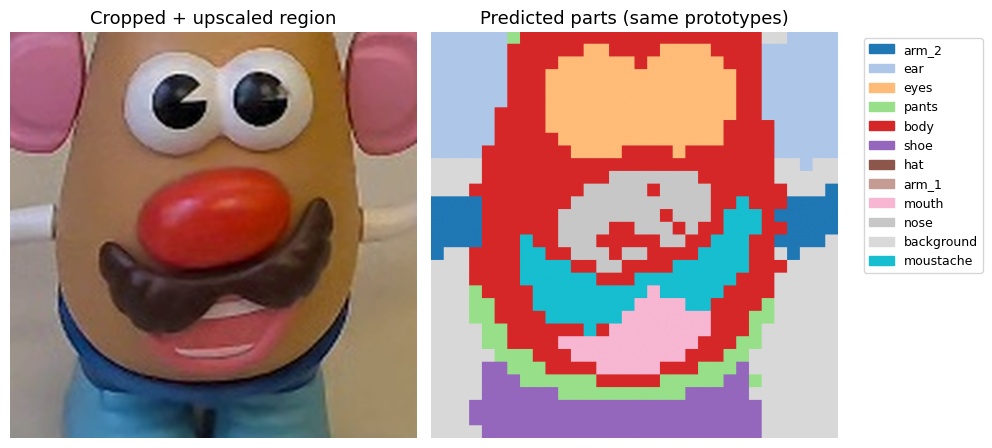

In [11]:
# Cell 8b: crop the nose/moustache/mouth cluster, upscale it, and classify at higher effective resolution

CROP_BOX = (360, 600, 520, 770)  # fill in from Cell 8a
UPSCALE_SIZE = (512, 512)

crop = test_image_full.crop(CROP_BOX)
crop_upscaled = crop.resize(UPSCALE_SIZE, Image.Resampling.LANCZOS)

crop_features, crop_h_feat, crop_w_feat, _ = extract_spatial_features(crop_upscaled)
crop_features_np = crop_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()

crop_features_flat = crop_features_np.reshape(-1, crop_features_np.shape[-1])
crop_features_norm = normalize(crop_features_flat)
similarities_crop = crop_features_norm @ prototype_matrix_norm.T
predicted_indices_crop = similarities_crop.argmax(axis=1)
predicted_labels_crop = np.array(label_names)[predicted_indices_crop].reshape(crop_h_feat, crop_w_feat)

color_grid_crop = np.zeros((crop_h_feat, crop_w_feat, 3))
for row in range(crop_h_feat):
    for col in range(crop_w_feat):
        color_grid_crop[row, col] = label_to_color[predicted_labels_crop[row, col]]
color_grid_crop_resized = cv2.resize(color_grid_crop, crop_upscaled.size, interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(crop_upscaled)
axes[0].set_title("Cropped + upscaled region", fontsize=13)
axes[0].axis("off")
axes[1].imshow(color_grid_crop_resized)
axes[1].set_title("Predicted parts (same prototypes)", fontsize=13)
axes[1].axis("off")
legend_patches = [mpatches.Patch(color=label_to_color[l], label=l) for l in label_names]
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Cell 9: build a contact sheet of many frames at once, to pick candidates quickly
import glob
import os

FRAMES_FOLDER = "../data/extracted_frames/"
THUMB_SIZE = (150, 150)
COLUMNS = 6

frame_paths = sorted(glob.glob(os.path.join(FRAMES_FOLDER, "*.jpg")))
print(f"Found {len(frame_paths)} frames total")

rows = (len(frame_paths) + COLUMNS - 1) // COLUMNS
sheet = Image.new("RGB", (COLUMNS * THUMB_SIZE[0], rows * (THUMB_SIZE[1] + 20)), "white")

from PIL import ImageDraw
draw = ImageDraw.Draw(sheet)

for i, path in enumerate(frame_paths):
    thumb = Image.open(path).convert("RGB")
    thumb.thumbnail(THUMB_SIZE)
    x = (i % COLUMNS) * THUMB_SIZE[0]
    y = (i // COLUMNS) * (THUMB_SIZE[1] + 20)
    sheet.paste(thumb, (x, y))
    draw.text((x, y + THUMB_SIZE[1]), os.path.basename(path)[:20], fill="black")

sheet.save("../data/contact_sheet.jpg")
print("Saved contact sheet, open it to browse quickly")

Found 733 frames total
Saved contact sheet, open it to browse quickly


In [13]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Cell 10: how separated are the prototypes, really?
label_order = list(prototypes.keys())
proto_matrix = normalize(np.stack([prototypes[l] for l in label_order]))
sim_matrix = proto_matrix @ proto_matrix.T

import pandas as pd
sim_df = pd.DataFrame(sim_matrix, index=label_order, columns=label_order)
print(sim_df.round(2))

            arm_2   ear  eyes  pants  body  shoe   hat  arm_1  mouth  nose  \
arm_2        1.00  0.82  0.77   0.77  0.77  0.79  0.71   0.95   0.80  0.77   
ear          0.82  1.00  0.77   0.79  0.83  0.78  0.76   0.80   0.80  0.81   
eyes         0.77  0.77  1.00   0.74  0.85  0.72  0.69   0.75   0.78  0.75   
pants        0.77  0.79  0.74   1.00  0.85  0.93  0.81   0.76   0.82  0.86   
body         0.77  0.83  0.85   0.85  1.00  0.80  0.79   0.75   0.87  0.84   
shoe         0.79  0.78  0.72   0.93  0.80  1.00  0.77   0.77   0.80  0.82   
hat          0.71  0.76  0.69   0.81  0.79  0.77  1.00   0.70   0.74  0.75   
arm_1        0.95  0.80  0.75   0.76  0.75  0.77  0.70   1.00   0.78  0.78   
mouth        0.80  0.80  0.78   0.82  0.87  0.80  0.74   0.78   1.00  0.84   
nose         0.77  0.81  0.75   0.86  0.84  0.82  0.75   0.78   0.84  1.00   
background   0.60  0.60  0.55   0.66  0.66  0.64  0.60   0.60   0.59  0.61   
moustache    0.79  0.81  0.75   0.84  0.83  0.80  0.77   0.81   

In [15]:
# Cell 11: classify via k-nearest-neighbor over ALL pooled reference patches
# (instead of collapsing each class into a single mean vector)

all_vectors, all_labels = [], []
for label, chunks in label_to_vectors.items():
    vectors = np.concatenate(chunks, axis=0)
    all_vectors.append(vectors)
    all_labels.extend([label] * vectors.shape[0])
all_vectors = normalize(np.concatenate(all_vectors, axis=0))
all_labels = np.array(all_labels)

def classify_nn(test_features_np, k=5):
    h, w, c = test_features_np.shape
    flat = normalize(test_features_np.reshape(-1, c))
    sims = flat @ all_vectors.T  # [num_test_patches, num_reference_patches]
    topk_idx = np.argpartition(-sims, kth=k-1, axis=1)[:, :k]
    predicted = []
    for i in range(flat.shape[0]):
        neighbor_labels = all_labels[topk_idx[i]]
        values, counts = np.unique(neighbor_labels, return_counts=True)
        predicted.append(values[np.argmax(counts)])
    return np.array(predicted).reshape(h, w)

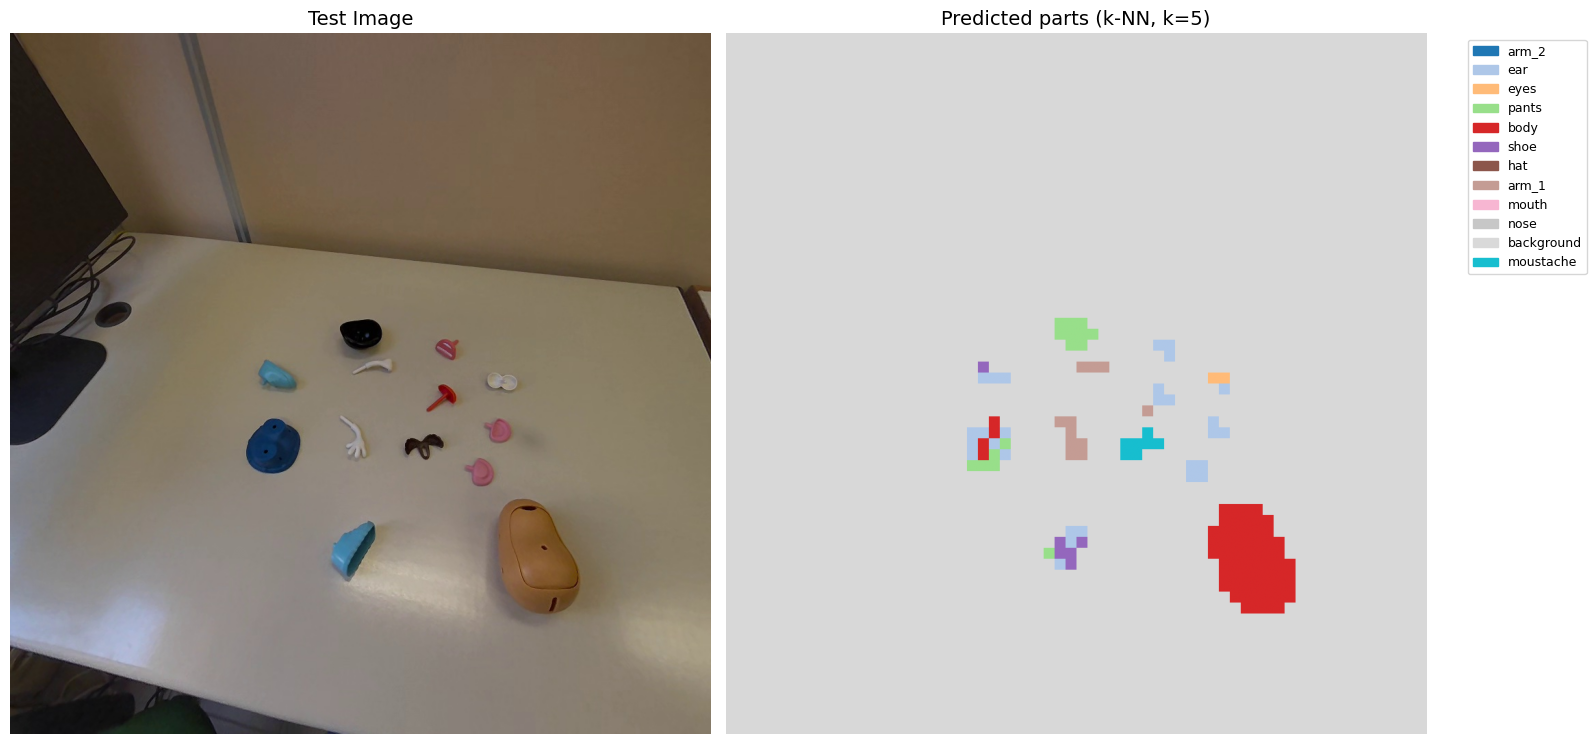

In [16]:
# Cell 12: run the k-NN classifier on a test frame and visualize it

TEST_IMAGE_PATH = "../data/extracted_frames/2_disassembled_caos_f0016.jpg"

test_image = Image.open(TEST_IMAGE_PATH).convert("RGB")
test_features, test_h_feat, test_w_feat, _ = extract_spatial_features(test_image)
test_features_np = test_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()

predicted_labels_nn = classify_nn(test_features_np, k=5)

color_grid_nn = np.zeros((test_h_feat, test_w_feat, 3))
for row in range(test_h_feat):
    for col in range(test_w_feat):
        color_grid_nn[row, col] = label_to_color[predicted_labels_nn[row, col]]

color_grid_nn_resized = cv2.resize(
    color_grid_nn, (test_image.width, test_image.height), interpolation=cv2.INTER_NEAREST
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(test_image)
axes[0].set_title("Test Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(color_grid_nn_resized)
axes[1].set_title("Predicted parts (k-NN, k=5)", fontsize=14)
axes[1].axis("off")

legend_patches = [mpatches.Patch(color=label_to_color[l], label=l) for l in label_names]
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
# Cell 13: cheap, model-free check — does SHAPE separate the two confused pairs?
import json
from shapely.geometry import Polygon

ANNOTATED_JSONS = [
    "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json",
    "../data/extracted_frames/caos_f0149.json",
    "../data/extracted_frames/assembly_1_f0073.json",
    "../data/extracted_frames/5_assembled_f0002.json",
    "../data/extracted_frames/5_assembled_f0019.json",
]

shape_stats = {"pants": [], "shoe": [], "arm_1": [], "arm_2": []}

for json_path in ANNOTATED_JSONS:
    with open(json_path) as f:
        annotations = json.load(f)
    for shape in annotations["shapes"]:
        label = shape["label"]
        if label in shape_stats:
            poly = Polygon(shape["points"])
            minx, miny, maxx, maxy = poly.bounds
            width, height = maxx - minx, maxy - miny
            shape_stats[label].append({
                "aspect_ratio": width / height,
                "area": poly.area,
            })

for label, entries in shape_stats.items():
    print(f"\n{label} ({len(entries)} instances):")
    for e in entries:
        print(f"  aspect_ratio={e['aspect_ratio']:.2f}  area={e['area']:.0f}")


pants (5 instances):
  aspect_ratio=1.74  area=1989
  aspect_ratio=1.32  area=7856
  aspect_ratio=2.07  area=1040
  aspect_ratio=2.30  area=798
  aspect_ratio=2.15  area=870

shoe (10 instances):
  aspect_ratio=0.82  area=2118
  aspect_ratio=0.70  area=1060
  aspect_ratio=0.76  area=3906
  aspect_ratio=0.78  area=4191
  aspect_ratio=0.63  area=2771
  aspect_ratio=0.75  area=2819
  aspect_ratio=0.77  area=2056
  aspect_ratio=0.78  area=1964
  aspect_ratio=0.83  area=2255
  aspect_ratio=1.09  area=1636

arm_1 (5 instances):
  aspect_ratio=2.76  area=873
  aspect_ratio=1.29  area=3960
  aspect_ratio=1.13  area=1591
  aspect_ratio=1.03  area=1354
  aspect_ratio=0.81  area=1383

arm_2 (4 instances):
  aspect_ratio=0.76  area=418
  aspect_ratio=1.65  area=1324
  aspect_ratio=1.70  area=1093
  aspect_ratio=1.28  area=1123


In [18]:
# Cell 13b: rotation-invariant shape check for arm_1/arm_2 (and a sanity re-check on pants/shoe)
shape_stats_rot = {"pants": [], "shoe": [], "arm_1": [], "arm_2": []}

for json_path in ANNOTATED_JSONS:
    with open(json_path) as f:
        annotations = json.load(f)
    for shape in annotations["shapes"]:
        label = shape["label"]
        if label in shape_stats_rot:
            poly = Polygon(shape["points"])
            min_rect = poly.minimum_rotated_rectangle
            coords = list(min_rect.exterior.coords)
            side1 = ((coords[0][0]-coords[1][0])**2 + (coords[0][1]-coords[1][1])**2) ** 0.5
            side2 = ((coords[1][0]-coords[2][0])**2 + (coords[1][1]-coords[2][1])**2) ** 0.5
            long_side, short_side = max(side1, side2), min(side1, side2)
            shape_stats_rot[label].append({
                "aspect_ratio": long_side / short_side,
                "area": poly.area,
            })

for label, entries in shape_stats_rot.items():
    print(f"\n{label} ({len(entries)} instances):")
    for e in entries:
        print(f"  aspect_ratio={e['aspect_ratio']:.2f}  area={e['area']:.0f}")


pants (5 instances):
  aspect_ratio=1.79  area=1989
  aspect_ratio=1.43  area=7856
  aspect_ratio=2.33  area=1040
  aspect_ratio=2.51  area=798
  aspect_ratio=2.51  area=870

shoe (10 instances):
  aspect_ratio=1.36  area=2118
  aspect_ratio=1.41  area=1060
  aspect_ratio=1.47  area=3906
  aspect_ratio=1.39  area=4191
  aspect_ratio=1.58  area=2771
  aspect_ratio=1.40  area=2819
  aspect_ratio=1.29  area=2056
  aspect_ratio=1.24  area=1964
  aspect_ratio=1.38  area=2255
  aspect_ratio=1.02  area=1636

arm_1 (5 instances):
  aspect_ratio=3.08  area=873
  aspect_ratio=2.58  area=3960
  aspect_ratio=1.86  area=1591
  aspect_ratio=1.92  area=1354
  aspect_ratio=1.98  area=1383

arm_2 (4 instances):
  aspect_ratio=2.23  area=418
  aspect_ratio=1.63  area=1324
  aspect_ratio=1.90  area=1093
  aspect_ratio=1.90  area=1123


In [19]:
# Cell 13c (fix): contour-complexity check (open hand vs closed fist), scale-normalized
import cv2

def contour_features(points, area):
    scale = np.sqrt(area) if area > 0 else 1.0
    pts_int = np.round(np.array(points, dtype=np.float32)).astype(np.int32).reshape((-1, 1, 2))
    hull_idx = np.unique(cv2.convexHull(pts_int, returnPoints=False).flatten()).reshape(-1, 1)
    if len(hull_idx) < 3:
        return 0, 0.0
    try:
        defects = cv2.convexityDefects(pts_int, hull_idx)
    except cv2.error:
        return 0, 0.0
    if defects is None:
        return 0, 0.0
    defects = defects.reshape(-1, 4)  # normalize to (n, 4) regardless of OpenCV's returned shape
    depths = (defects[:, 3] / 256.0) / scale
    significant = depths[depths > 0.05]
    return len(significant), float(depths.max())

shape_stats_contour = {"arm_1": [], "arm_2": []}
for json_path in ANNOTATED_JSONS:
    with open(json_path) as f:
        annotations = json.load(f)
    for shape in annotations["shapes"]:
        label = shape["label"]
        if label in shape_stats_contour:
            poly = Polygon(shape["points"])
            n_defects, max_depth = contour_features(shape["points"], poly.area)
            shape_stats_contour[label].append({"n_defects": n_defects, "max_depth": round(max_depth, 3)})

for label, entries in shape_stats_contour.items():
    print(f"\n{label} ({len(entries)} instances):")
    for e in entries:
        print(f"  n_defects={e['n_defects']}  max_depth={e['max_depth']}")


arm_1 (5 instances):
  n_defects=5  max_depth=0.516
  n_defects=5  max_depth=0.608
  n_defects=4  max_depth=0.464
  n_defects=5  max_depth=0.435
  n_defects=4  max_depth=0.447

arm_2 (4 instances):
  n_defects=2  max_depth=0.573
  n_defects=3  max_depth=0.315
  n_defects=2  max_depth=0.145
  n_defects=2  max_depth=0.189


In [20]:
# Cell 15: build prototypes from an arbitrary subset of reference frames (reusable)

def build_prototypes(reference_frames):
    label_to_vectors = {}
    for image_path, json_path in reference_frames:
        print(f"Processing {image_path}...")
        reference_image = Image.open(image_path).convert("RGB")
        ref_features, ref_h_feat, ref_w_feat, (ref_resized_w, ref_resized_h) = extract_spatial_features(reference_image)
        ref_features_np = ref_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()

        with open(json_path) as f:
            annotations = json.load(f)
        scale_x = ref_resized_w / annotations["imageWidth"]
        scale_y = ref_resized_h / annotations["imageHeight"]
        polygons = [(shape["label"], Polygon(shape["points"])) for shape in annotations["shapes"]]

        frame_patch_labels = np.full((ref_h_feat, ref_w_feat), "background", dtype=object)
        for row in range(ref_h_feat):
            for col in range(ref_w_feat):
                cx = ((col + 0.5) * patch_size) / scale_x
                cy = ((row + 0.5) * patch_size) / scale_y
                point = Point(cx, cy)
                for label, polygon in polygons:
                    if polygon.contains(point):
                        frame_patch_labels[row, col] = label
                        break

        for label in set(frame_patch_labels.flatten()):
            mask = (frame_patch_labels == label)
            label_to_vectors.setdefault(label, []).append(ref_features_np[mask])

    prototypes = {label: np.concatenate(chunks, axis=0).mean(axis=0) for label, chunks in label_to_vectors.items()}
    print(f"\nBuilt {len(prototypes)} prototypes from {len(reference_frames)} frame(s): {list(prototypes.keys())}")
    return prototypes

SESSION_A_FRAMES = [
    ("../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg",
     "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json"),
    ("../data/extracted_frames/5_assembled_f0002.jpg",
     "../data/extracted_frames/5_assembled_f0002.json"),
    ("../data/extracted_frames/5_assembled_f0019.jpg",
     "../data/extracted_frames/5_assembled_f0019.json"),
]

SESSION_B_FRAMES = [
    ("../data/extracted_frames/caos_f0149.jpg",
     "../data/extracted_frames/caos_f0149.json"),
    ("../data/extracted_frames/assembly_1_f0073.jpg",
     "../data/extracted_frames/assembly_1_f0073.json"),
]

print("=== Session A only ===")
prototypes_sessionA = build_prototypes(SESSION_A_FRAMES)
print("\n=== Session B only ===")
prototypes_sessionB = build_prototypes(SESSION_B_FRAMES)

=== Session A only ===
Processing ../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg...
Processing ../data/extracted_frames/5_assembled_f0002.jpg...
Processing ../data/extracted_frames/5_assembled_f0019.jpg...

Built 12 prototypes from 3 frame(s): ['arm_2', 'ear', 'eyes', 'pants', 'body', 'shoe', 'hat', 'arm_1', 'mouth', 'nose', 'background', 'moustache']

=== Session B only ===
Processing ../data/extracted_frames/caos_f0149.jpg...
Processing ../data/extracted_frames/assembly_1_f0073.jpg...

Built 12 prototypes from 2 frame(s): ['ear', 'eyes', 'body', 'shoe', 'nose', 'hat', 'arm_1', 'mouth', 'pants', 'background', 'moustache', 'arm_2']


In [30]:
# Cell 16 (replaces old 16 + 16b): consistent global colors + reusable classification/plot
import matplotlib.patches as mpatches
import cv2

def normalize(v):
    return v / (np.linalg.norm(v, axis=-1, keepdims=True) + 1e-8)

# Cell 16 — just update this one line, then rilancia tutta la Cella 16 com'era
ALL_LABELS = ['nose', 'eyes', 'ear', 'mouth', 'moustache', 'background', 'hat', 'shoe', 'pants', 'arm_1', 'arm_2', 'body', 'hand']
_cmap = plt.get_cmap("tab20")
GLOBAL_LABEL_TO_COLOR = {label: _cmap(i / len(ALL_LABELS))[:3] for i, label in enumerate(ALL_LABELS)}
GLOBAL_LABEL_TO_COLOR["background"] = (0.85, 0.85, 0.85)

def classify_and_plot(test_image_path, prototypes, title_suffix=""):
    label_names = list(prototypes.keys())
    label_to_color = GLOBAL_LABEL_TO_COLOR  # fixed mapping, same colors across every call

    test_image = Image.open(test_image_path).convert("RGB")
    test_features, test_h_feat, test_w_feat, _ = extract_spatial_features(test_image)
    test_features_np = test_features.squeeze(0).permute(1, 2, 0).float().cpu().numpy()

    prototype_matrix = normalize(np.stack([prototypes[l] for l in label_names]))
    test_features_flat = test_features_np.reshape(-1, test_features_np.shape[-1])
    test_features_norm = normalize(test_features_flat)
    similarities = test_features_norm @ prototype_matrix.T
    predicted_indices = similarities.argmax(axis=1)
    predicted_labels = np.array(label_names)[predicted_indices].reshape(test_h_feat, test_w_feat)

    color_grid = np.zeros((test_h_feat, test_w_feat, 3))
    for row in range(test_h_feat):
        for col in range(test_w_feat):
            color_grid[row, col] = label_to_color[predicted_labels[row, col]]
    color_grid_resized = cv2.resize(color_grid, test_image.size, interpolation=cv2.INTER_NEAREST)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(test_image)
    axes[0].set_title("Test image", fontsize=14)
    axes[0].axis("off")
    axes[1].imshow(color_grid_resized)
    axes[1].set_title(f"Predicted parts {title_suffix}", fontsize=14)
    axes[1].axis("off")
    # legend always shows ALL labels, in the same fixed order, every time
    legend_patches = [mpatches.Patch(color=GLOBAL_LABEL_TO_COLOR[l], label=l) for l in ALL_LABELS]
    axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()
    return predicted_labels

Session A prototypes -> tested on a Session B frame (never seen by these prototypes):


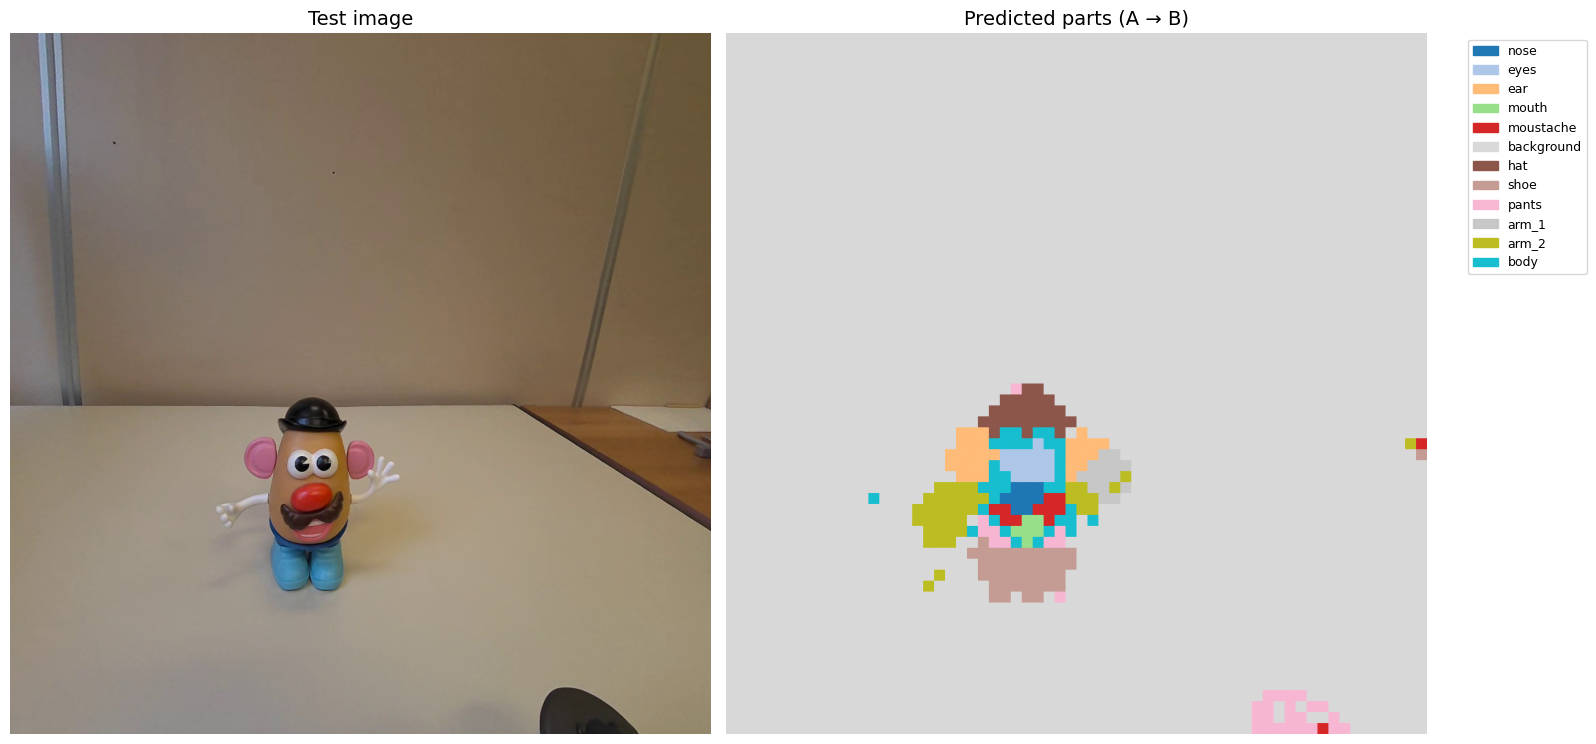

In [22]:
# Cell 17: the cross-session test itself — two directions

print("Session A prototypes -> tested on a Session B frame (never seen by these prototypes):")
_ = classify_and_plot("../data/extracted_frames/caos_f0393.jpg", prototypes_sessionA, "(A → B)")

Session B prototypes -> tested on a Session A frame (never seen by these prototypes):


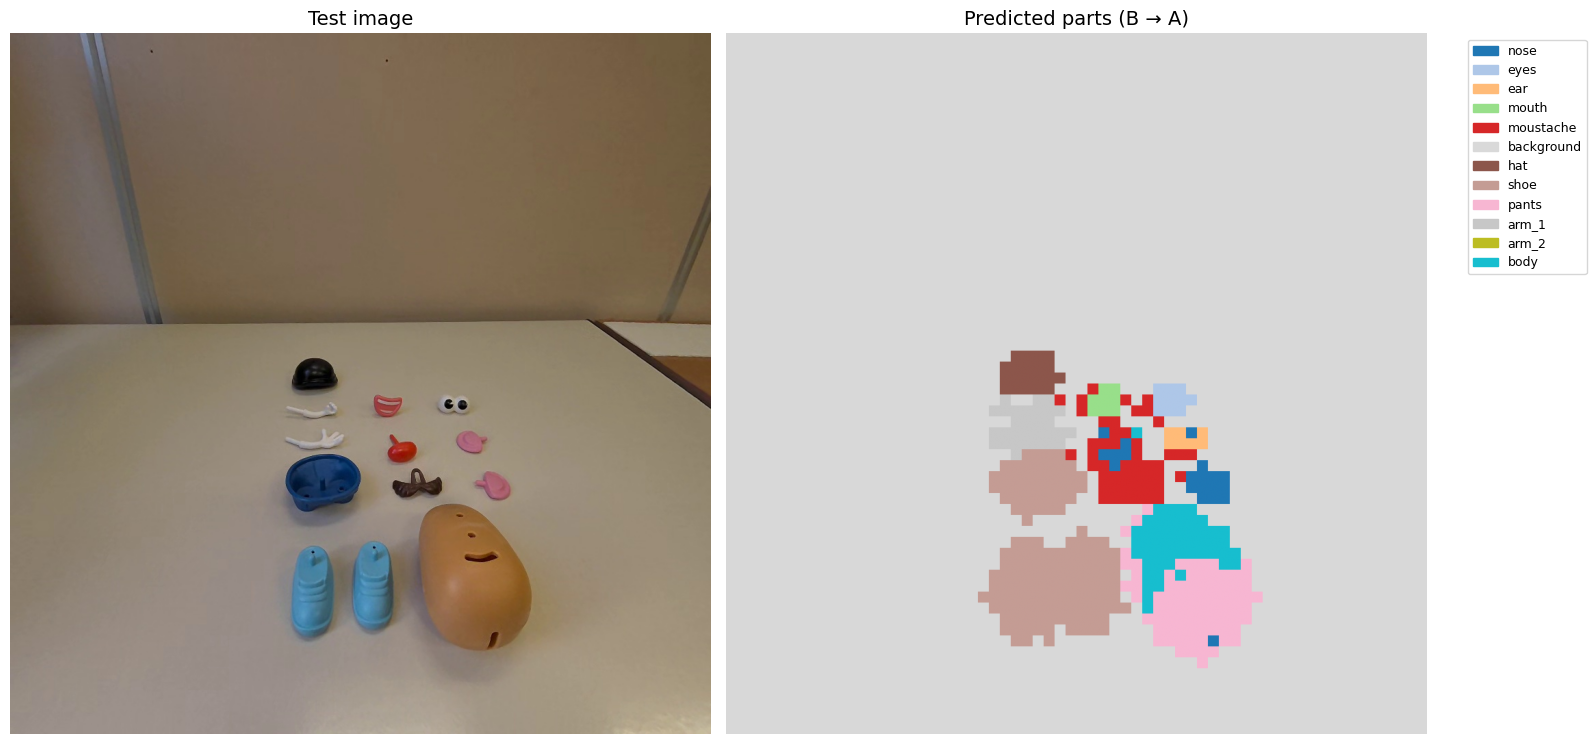

In [23]:
# Cell 18: the other direction
print("Session B prototypes -> tested on a Session A frame (never seen by these prototypes):")
_ = classify_and_plot("../data/extracted_frames/3_disassembled_ordered_f0001.jpg", prototypes_sessionB, "(B → A)")

In [24]:
# Cell 19: shape descriptors computed on blobs from the coarse patch-grid classification
from scipy import ndimage

def blob_shape_descriptors(predicted_labels, target_labels):
    """
    predicted_labels: 2D array of string labels (returned by classify_and_plot)
    target_labels: e.g. {'pants', 'shoe'} or {'arm_1', 'arm_2'}
    Returns one dict per connected blob found among those labels.
    """
    mask = np.isin(predicted_labels, list(target_labels)).astype(np.uint8)
    labeled_mask, n_blobs = ndimage.label(mask, structure=np.ones((3, 3)))  # 8-connectivity

    results = []
    for blob_id in range(1, n_blobs + 1):
        blob_mask = (labeled_mask == blob_id).astype(np.uint8)
        if blob_mask.sum() < 3:  # skip 1-2 patch noise specks
            continue
        contours, _ = cv2.findContours(blob_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        if len(contour) < 3:
            continue

        labels_in_blob = predicted_labels[blob_mask.astype(bool)]
        values, counts = np.unique(labels_in_blob, return_counts=True)
        majority_label = values[np.argmax(counts)]

        rect = cv2.minAreaRect(contour)
        w, h = rect[1]
        aspect_ratio = max(w, h) / min(w, h) if min(w, h) > 0 else 0

        n_defects = 0
        hull_idx = cv2.convexHull(contour, returnPoints=False)
        if hull_idx is not None and len(hull_idx) >= 3:
            try:
                defects = cv2.convexityDefects(contour, hull_idx)
            except cv2.error:
                defects = None
            if defects is not None:
                scale = np.sqrt(cv2.contourArea(contour)) or 1.0
                depths = (defects.reshape(-1, 4)[:, 3] / 256.0) / scale
                n_defects = int((depths > 0.05).sum())

        results.append({
            "majority_label": majority_label,
            "n_patches": int(blob_mask.sum()),
            "aspect_ratio": round(aspect_ratio, 2),
            "n_defects": n_defects,
        })
    return results

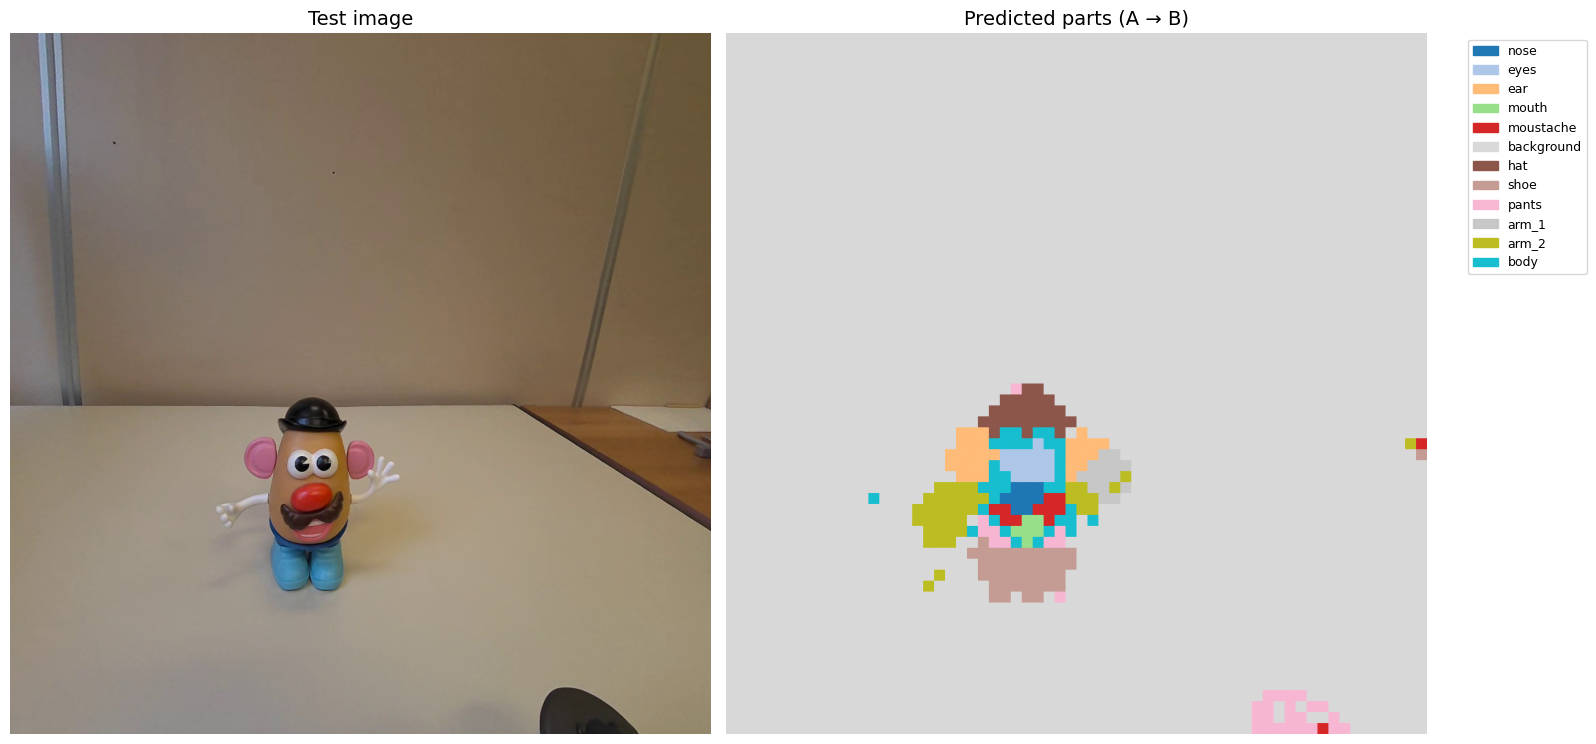

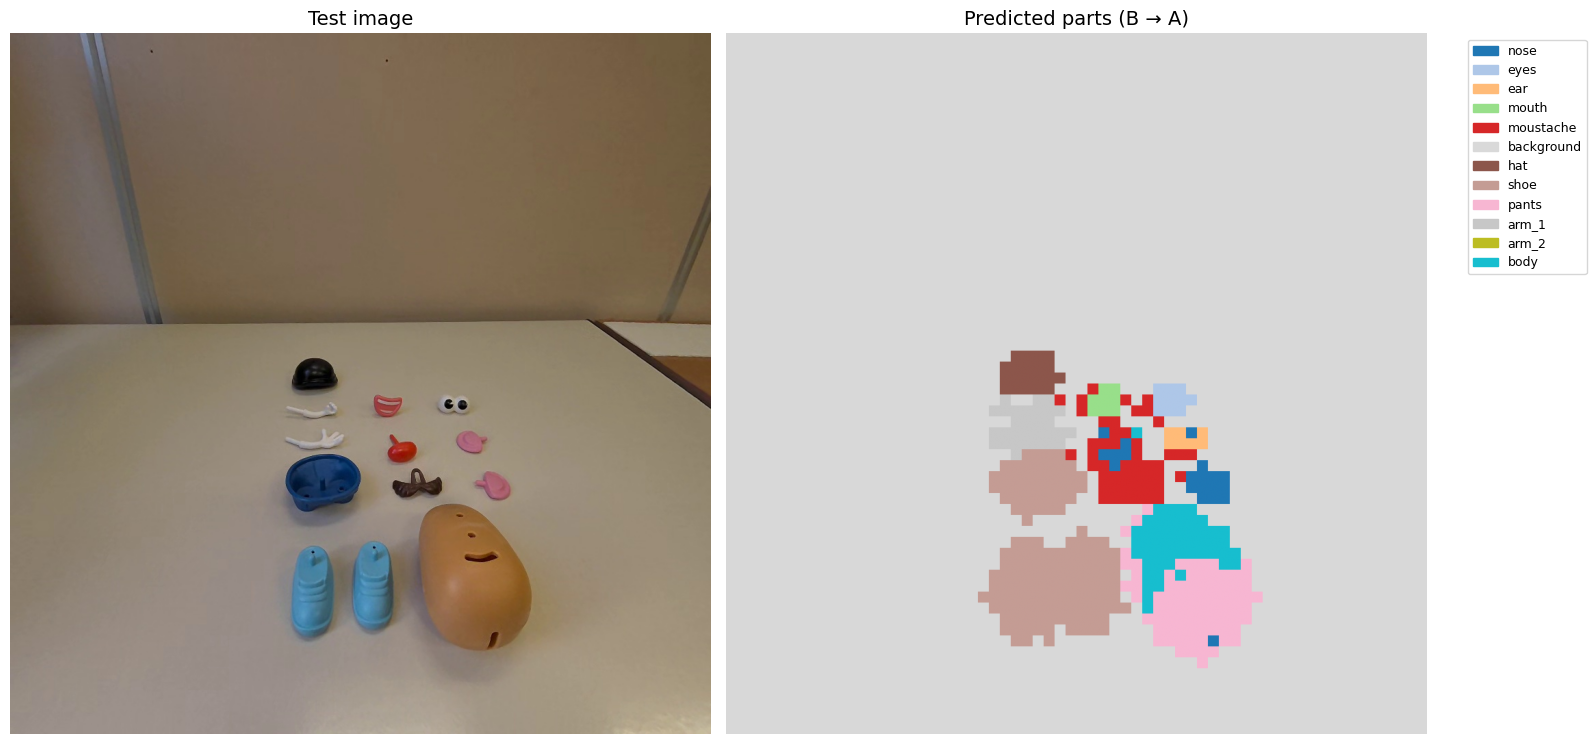

=== pants/shoe blobs, A→B frame ===
{'majority_label': np.str_('shoe'), 'n_patches': 48, 'aspect_ratio': 1.33, 'n_defects': 6}
{'majority_label': np.str_('pants'), 'n_patches': 22, 'aspect_ratio': 2.67, 'n_defects': 2}

=== arm_1/arm_2 blobs, A→B frame ===
{'majority_label': np.str_('arm_1'), 'n_patches': 24, 'aspect_ratio': 1.6, 'n_defects': 1}
{'majority_label': np.str_('arm_2'), 'n_patches': 28, 'aspect_ratio': 1.5, 'n_defects': 2}

=== pants/shoe blobs, B→A frame ===
{'majority_label': np.str_('shoe'), 'n_patches': 42, 'aspect_ratio': 1.0, 'n_defects': 2}
{'majority_label': np.str_('pants'), 'n_patches': 3, 'aspect_ratio': 0, 'n_defects': 0}
{'majority_label': np.str_('shoe'), 'n_patches': 109, 'aspect_ratio': 1.53, 'n_defects': 5}
{'majority_label': np.str_('pants'), 'n_patches': 69, 'aspect_ratio': 1.22, 'n_defects': 7}

=== arm_1/arm_2 blobs, B→A frame ===
{'majority_label': np.str_('arm_1'), 'n_patches': 30, 'aspect_ratio': 1.4, 'n_defects': 5}


In [25]:
# Cell 20: run it on today's cross-session predictions
predicted_A_to_B = classify_and_plot("../data/extracted_frames/caos_f0393.jpg", prototypes_sessionA, "(A → B)")
predicted_B_to_A = classify_and_plot("../data/extracted_frames/3_disassembled_ordered_f0001.jpg", prototypes_sessionB, "(B → A)")

print("=== pants/shoe blobs, A→B frame ===")
for r in blob_shape_descriptors(predicted_A_to_B, {"pants", "shoe"}):
    print(r)

print("\n=== arm_1/arm_2 blobs, A→B frame ===")
for r in blob_shape_descriptors(predicted_A_to_B, {"arm_1", "arm_2"}):
    print(r)

print("\n=== pants/shoe blobs, B→A frame ===")
for r in blob_shape_descriptors(predicted_B_to_A, {"pants", "shoe"}):
    print(r)

print("\n=== arm_1/arm_2 blobs, B→A frame ===")
for r in blob_shape_descriptors(predicted_B_to_A, {"arm_1", "arm_2"}):
    print(r)

In [26]:
# Cell 21 (replaces the sharpness-based version): central-crop frame differencing
def compute_motion_score(frame_bgr, prev_gray_crop, resize_to=(320, 320)):
    """Returns (motion_score, current_gray_crop_to_reuse_as_prev_next_time). motion_score is None on the first frame."""
    small = cv2.resize(frame_bgr, resize_to)
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    crop = gray[h//4:h - h//4, w//4:w - w//4]  # central 50%, less affected by head/camera panning
    if prev_gray_crop is None:
        return None, crop
    diff = cv2.absdiff(crop, prev_gray_crop)
    return diff.mean(), crop

In [38]:
# Cell 22 (updated): hide hands entirely, and avoid overlapping labels
from scipy import ndimage

MIN_BLOB_PATCHES = 5

def annotate_frame(frame_bgr, status, predicted_labels=None):
    overlay = frame_bgr.copy()
    if status == "locked" and predicted_labels is not None:
        h_feat, w_feat = predicted_labels.shape
        scale_x = frame_bgr.shape[1] / w_feat
        scale_y = frame_bgr.shape[0] / h_feat

        color_grid = np.zeros((h_feat, w_feat, 3), dtype=np.uint8)
        for row in range(h_feat):
            for col in range(w_feat):
                label = predicted_labels[row, col]
                c = GLOBAL_LABEL_TO_COLOR["background"] if label == "hand" else GLOBAL_LABEL_TO_COLOR[label]
                color_grid[row, col] = (int(c[2]*255), int(c[1]*255), int(c[0]*255))
        color_grid_resized = cv2.resize(color_grid, (frame_bgr.shape[1], frame_bgr.shape[0]), interpolation=cv2.INTER_NEAREST)

        # hand pixels: show the raw frame, no tint at all
        hand_mask = (predicted_labels == "hand").astype(np.uint8)
        hand_mask_resized = cv2.resize(hand_mask, (frame_bgr.shape[1], frame_bgr.shape[0]), interpolation=cv2.INTER_NEAREST).astype(bool)

        overlay = cv2.addWeighted(frame_bgr, 0.55, color_grid_resized, 0.45, 0)
        overlay[hand_mask_resized] = frame_bgr[hand_mask_resized]

        # draw one name per blob, nudging down if it would overlap an already-placed label
        placed_positions = []
        for label in set(np.unique(predicted_labels)) - {"background", "hand"}:
            label_mask = (predicted_labels == label)
            labeled_blobs, n_blobs = ndimage.label(label_mask, structure=np.ones((3, 3)))
            for blob_id in range(1, n_blobs + 1):
                blob = (labeled_blobs == blob_id)
                if blob.sum() < MIN_BLOB_PATCHES:
                    continue
                rows, cols = np.where(blob)
                px, py = int(cols.mean() * scale_x), int(rows.mean() * scale_y)

                while any(abs(px - ex) < 55 and abs(py - ey) < 16 for ex, ey in placed_positions):
                    py += 16
                placed_positions.append((px, py))

                cv2.putText(overlay, label, (px - 25, py), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 3, cv2.LINE_AA)
                cv2.putText(overlay, label, (px - 25, py), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1, cv2.LINE_AA)

        text, color = "LOCKED - classifying", (60, 200, 60)
    else:
        text, color = "scanning...", (60, 60, 220)

    cv2.rectangle(overlay, (0, 0), (overlay.shape[1], 40), (30, 30, 30), -1)
    cv2.putText(overlay, text, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)
    return overlay

In [ ]:
# Cell 23 (updated): main loop using central-crop frame differencing instead of sharpness
import os

VIDEO_PATH = "../data/raw_videos/assembly_2.mp4"
OUTPUT_PATH = "../outputs/perception_demo.mp4"
MOTION_THRESHOLD = 1.0         # below this = considered still (tune after watching a first pass)
STABLE_FRAMES_NEEDED = 5       # ~0.17s at 30fps of stability before locking
prototypes_for_demo = prototypes

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Could not open video at {VIDEO_PATH} — check the path"

fps = cap.get(cv2.CAP_PROP_FPS)
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Opened video: {w}x{h}, {fps:.1f}fps, {total_frames} frames")

writer = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
assert writer.isOpened(), f"Could not open VideoWriter for {OUTPUT_PATH}"

status = "scanning"
stable_count = 0
locked_labels = None
prev_gray_crop = None
frame_idx = 0

while True:
    ret, frame_bgr = cap.read()
    if not ret:
        break

    motion_score, prev_gray_crop = compute_motion_score(frame_bgr, prev_gray_crop)
    is_still = (motion_score is not None) and (motion_score < MOTION_THRESHOLD)

    if is_still:
        stable_count += 1
    else:
        stable_count = 0
        status = "scanning"
        locked_labels = None

    if stable_count >= STABLE_FRAMES_NEEDED and status == "scanning":
        pil_frame = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        feats, hf, wf, _ = extract_spatial_features(pil_frame)
        feats_np = feats.squeeze(0).permute(1, 2, 0).float().cpu().numpy()
        proto_names = list(prototypes_for_demo.keys())
        proto_matrix = normalize(np.stack([prototypes_for_demo[l] for l in proto_names]))
        sims = normalize(feats_np.reshape(-1, feats_np.shape[-1])) @ proto_matrix.T

        best_idx = sims.argmax(axis=1)
        best_sim = sims.max(axis=1)
        bg_sim = sims[:, proto_names.index("background")]
        predicted_flat = np.array(proto_names)[best_idx]

        CONFIDENCE_MARGIN = 0.03  # tune: alza se vedi ancora oggetti "fantasma", abbassa se sparisce troppo
        uncertain = (best_sim - bg_sim) < CONFIDENCE_MARGIN
        predicted_flat[uncertain] = "background"

        locked_labels = predicted_flat.reshape(hf, wf)
        status = "locked"

    writer.write(annotate_frame(frame_bgr, status, locked_labels))
    frame_idx += 1
    if frame_idx % 300 == 0:
        print(f"{frame_idx}/{total_frames} frames processed...")

cap.release()
writer.release()
assert frame_idx > 0, "Zero frames were read — the video path was almost certainly wrong"
print(f"Done: {frame_idx} frames written to {OUTPUT_PATH}")

Opened video: 1024x1024, 30.0fps, 1024 frames
300/1024 frames processed...
600/1024 frames processed...
900/1024 frames processed...
Done: 1024 frames written to ../outputs/perception_demo_1.mp4


In [29]:
# Cell 24: rebuild the main "prototypes" (used by the video demo) with all 6 reference frames

ALL_REFERENCE_FRAMES = [
    ("../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg",
     "../data/extracted_frames/1_disassembled_controlled_caos_f0001.json"),
    ("../data/extracted_frames/caos_f0149.jpg",
     "../data/extracted_frames/caos_f0149.json"),
    ("../data/extracted_frames/assembly_1_f0073.jpg",
     "../data/extracted_frames/assembly_1_f0073.json"),
    ("../data/extracted_frames/5_assembled_f0002.jpg",
     "../data/extracted_frames/5_assembled_f0002.json"),
    ("../data/extracted_frames/5_assembled_f0019.jpg",
     "../data/extracted_frames/5_assembled_f0019.json"),
    ("../data/extracted_frames/caos_f0211.jpg",
     "../data/extracted_frames/caos_f0211.json"),
]

prototypes = build_prototypes(ALL_REFERENCE_FRAMES)

Processing ../data/extracted_frames/1_disassembled_controlled_caos_f0001.jpg...
Processing ../data/extracted_frames/caos_f0149.jpg...
Processing ../data/extracted_frames/assembly_1_f0073.jpg...
Processing ../data/extracted_frames/5_assembled_f0002.jpg...
Processing ../data/extracted_frames/5_assembled_f0019.jpg...
Processing ../data/extracted_frames/caos_f0211.jpg...

Built 13 prototypes from 6 frame(s): ['arm_2', 'ear', 'eyes', 'pants', 'body', 'shoe', 'hat', 'arm_1', 'mouth', 'nose', 'background', 'moustache', 'hand']
